# Letter Translations

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/crawford/emnist/emnist-letters-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-letters-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-mnist-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-digits-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-bymerge-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-balanced-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-digits-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-balanced-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-mnist-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-letters-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-byclass-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-bymerge-test.csv
/kaggle/input/datasets/crawford/emnist/emnist-balanced-mapping.txt
/kaggle/input/datasets/crawford/emnist/emnist-mnist-train.csv
/kaggle/input/datasets/crawford/emnist/emnist-digits-mapping.txt
/kaggle/input/datasets/crawford/emnist/em

In [2]:
#/kaggle/input/emnist/emnist-letters-mapping.txt
# testing_letter = pd.read_csv('/kaggle/input/datasets/crawford/emnist/emnist-letters-test.csv')
training_letter = pd.read_csv('/kaggle/input/datasets/crawford/emnist/emnist-letters-train.csv')

In [3]:
#training_letters
y1 = np.array(training_letter.iloc[:,0].values) - 1
x1 = np.array(training_letter.iloc[:,1:].values) - 1
#testing_labels
# y2 = np.array(testing_letter.iloc[:,0].values)
# x2 = np.array(testing_letter.iloc[:,1:].values)
print(y1.shape)
print(x1.shape)

(88799,)
(88799, 784)


In [28]:
# print(y2.shape)
# print(x2.shape)

In [36]:
np.unique(y1)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25])

In [30]:
# np.unique(y2)

In [37]:
y1.shape

(88799,)

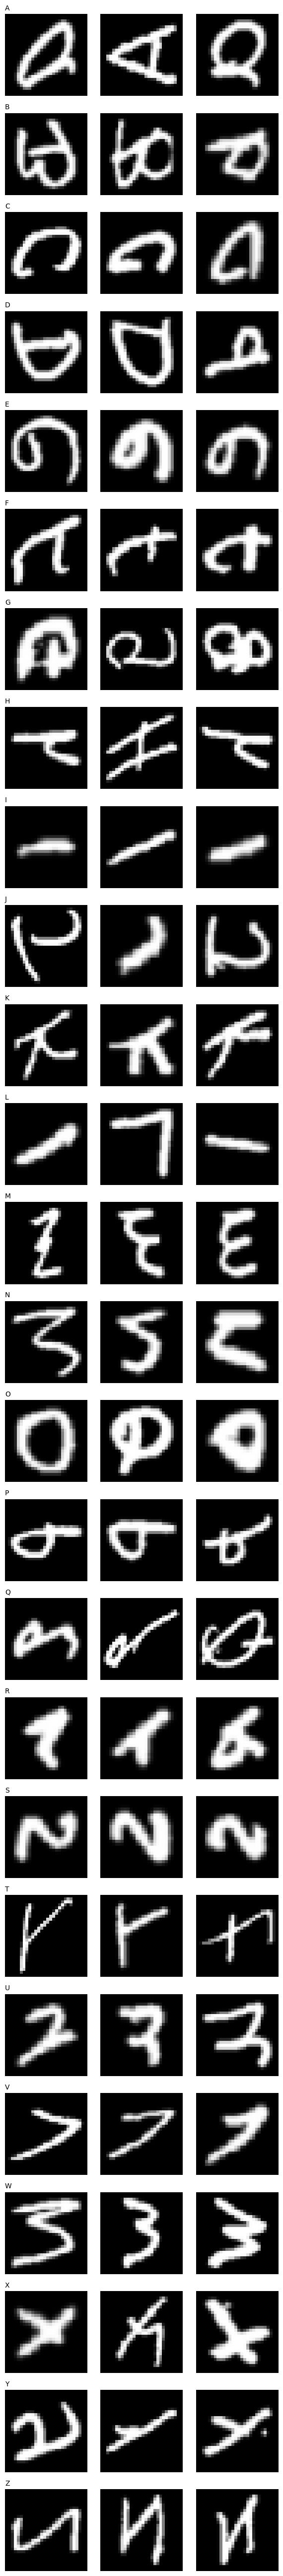

In [54]:
import matplotlib.pyplot as plt
import numpy as np

samples_per_class = 3
num_classes = 26

fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(6, 52))

for cls in range(num_classes):
    # Ambil semua index yang labelnya = cls
    idx = np.where(y1 == cls)[0][:samples_per_class]
    for col, i in enumerate(idx):
        axes[cls][col].imshow(x1[i].reshape(28, 28), cmap='gray')
        axes[cls][col].axis('off')
    # Label kelas di sisi kiri
    axes[cls][0].set_title(f"{chr(65+cls)}", fontsize=10, loc='left')

plt.tight_layout()
plt.show()

In [5]:
import tensorflow as tf

2026-05-31 13:17:00.856629: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780233421.041777      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780233421.099581      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780233421.573089      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780233421.573117      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780233421.573119      57 computation_placer.cc:177] computation placer alr

In [6]:
# Normalise and reshape data
train_images = x1 / 255.0
# test_images = x2 / 255.0

train_images_number = train_images.shape[0]
train_images_height = 28
train_images_width = 28
train_images_size = train_images_height*train_images_width

train_images = train_images.reshape(train_images_number, train_images_height, train_images_width, 1)

# test_images_number = test_images.shape[0]
# test_images_height = 28
# test_images_width = 28
# test_images_size = test_images_height*test_images_width

# test_images = test_images.reshape(test_images_number, test_images_height, test_images_width, 1)

In [67]:
train_images.shape[0]

88799

In [7]:
import scipy.ndimage
import numpy as np

print(f"Ukuran data sebelum augmentasi: {train_images.shape}")
print("Memproses augmentasi acak langsung pada data asli (in-place)...")

# Melakukan perulangan langsung pada indeks data asli
for i in range(train_images.shape[0]):
    img = train_images[i] # Mengambil referensi gambar ke-i (shape: 28, 28, 1)
    
    # Menentukan pilihan augmentasi secara acak:
    # 0: Tetap Asli
    # 1: Vertical Flip saja
    # 2: Rotate -90 derajat saja
    # 3: Keduanya (Vertical Flip + Rotate -90)
    choice = np.random.choice([0, 1, 2, 3])
    
    if choice == 1:
        # 1. Vertical Flip (Membalik atas-bawah)
        train_images[i] = np.flipud(img)
        
    elif choice == 2:
        # 2. Rotate -90 derajat (Berlawanan arah jarum jam)
        # reshape=False memastikan ukuran output tetap 28x28
        train_images[i] = scipy.ndimage.rotate(img, angle=-90, reshape=False, mode='nearest')
        
    elif choice == 3:
        # 3. Menerapkan Keduanya (Vertical Flip terlebih dahulu, kemudian di-rotate -90)
        img_flipped = np.flipud(img)
        train_images[i] = scipy.ndimage.rotate(img_flipped, angle=-90, reshape=False, mode='nearest')
        
    # Jika choice == 0, gambar dibiarkan asli tanpa diubah

print(f"Selesai! Ukuran data setelah augmentasi tetap: {train_images.shape}")

Ukuran data sebelum augmentasi: (88799, 28, 28, 1)
Memproses augmentasi acak langsung pada data asli (in-place)...
Selesai! Ukuran data setelah augmentasi tetap: (88799, 28, 28, 1)


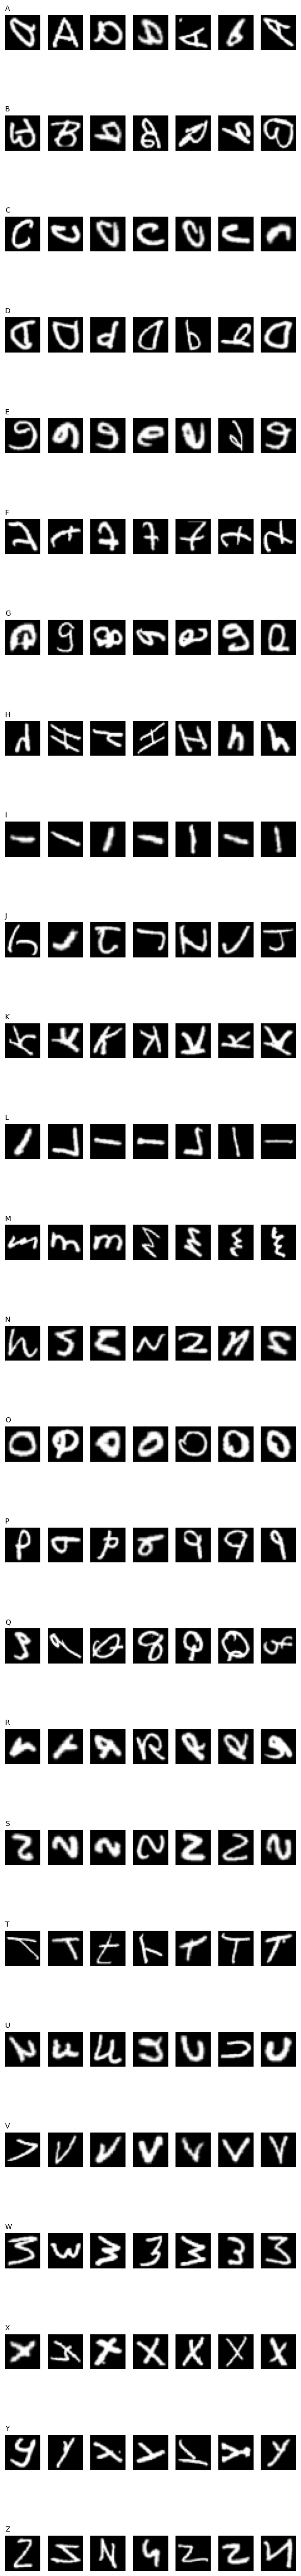

In [10]:
import matplotlib.pyplot as plt
import numpy as np

samples_per_class = 7
num_classes = 26

fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(6, 52))

for cls in range(num_classes):
    # Ambil semua index yang labelnya = cls
    idx = np.where(y1 == cls)[0][:samples_per_class]
    for col, i in enumerate(idx):
        axes[cls][col].imshow(train_images[i].reshape(28, 28), cmap='gray')
        axes[cls][col].axis('off')
    # Label kelas di sisi kiri
    axes[cls][0].set_title(f"{chr(65+cls)}", fontsize=10, loc='left')

plt.tight_layout()
plt.show()

In [41]:
# Transform labels
# number_of_classes = 26

# y1 = tf.keras.utils.to_categorical(y1, number_of_classes)
# y2 = tf.keras.utils.to_categorical(y2, number_of_classes)

In [11]:
from sklearn.model_selection import train_test_split
train_x,test_x,train_y,test_y = train_test_split(train_images,y1,test_size=0.01,random_state = 42, stratify=y1)
train_x,val_x,train_y,val_y = train_test_split(train_x,train_y,test_size=0.2,random_state = 42, stratify=train_y)

In [30]:
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
 
 
# ─────────────────────────────────────────
# 1. CUSTOM LAYER — Channel Attention (SE)
# ─────────────────────────────────────────
class ChannelAttention(layers.Layer):
    """Squeeze-and-Excitation channel attention."""
 
    def __init__(self, reduction_ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio
 
    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap = layers.GlobalAveragePooling2D()
        self.fc1 = layers.Dense(max(1, channels // self.reduction_ratio), activation="relu")
        self.fc2 = layers.Dense(channels, activation="sigmoid")
        self.reshape = layers.Reshape((1, 1, channels))
 
    def call(self, x):
        scale = self.gap(x)
        scale = self.fc1(scale)
        scale = self.fc2(scale)
        scale = self.reshape(scale)
        return x * scale
 
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"reduction_ratio": self.reduction_ratio})
        return cfg
 
 
# ─────────────────────────────────────────
# 2. CUSTOM LOSS — Label Smoothing CE
# ─────────────────────────────────────────
class LabelSmoothingCrossEntropy(keras.losses.Loss):
    def __init__(self, smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.smoothing = smoothing

    def call(self, y_true, y_pred):
        num_classes = tf.cast(tf.shape(y_pred)[-1], tf.float32)
        
        # y_true adalah integer 0–25, konversi ke one-hot di dalam loss
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_oh = tf.one_hot(y_true, tf.cast(num_classes, tf.int32))

        # Label smoothing
        smooth_labels = y_true_oh * (1.0 - self.smoothing) + self.smoothing / num_classes
        log_probs = tf.nn.log_softmax(y_pred, axis=-1)
        loss = -tf.reduce_sum(smooth_labels * log_probs, axis=-1)
        return tf.reduce_mean(loss)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"smoothing": self.smoothing})
        return cfg
 
    def get_config(self):
        cfg = super().get_config()
        cfg.update({"smoothing": self.smoothing})
        return cfg
 
 
# ─────────────────────────────────────────
# 3. CUSTOM CALLBACK — Verbose Epoch Log
# ─────────────────────────────────────────
class TrainingMonitor(keras.callbacks.Callback):
    """Prints a summary, reduces LR on plateau, and saves BEST FULL MODEL."""
 
    # 1. Ubah default extension dari .h5 ke .keras di sini
    def __init__(self, patience=3, factor=0.5, min_lr=1e-6, filepath="best_model.keras", monitor="val_accuracy"):
        super().__init__()
        self.patience  = patience
        self.factor    = factor
        self.min_lr    = min_lr
        self.filepath  = filepath
        self.monitor   = monitor  
        self._wait     = 0
        self.history   = []
        
        if "acc" in self.monitor:
            self._best = -np.inf  
            self._is_improvement = lambda current, best: current > best  
        else:
            self._best = np.inf   
            self._is_improvement = lambda current, best: current < best  
 
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_loss = logs.get("val_loss", float("inf"))
        lr = float(self.model.optimizer.learning_rate)
 
        self.history.append({**logs, "lr": lr, "epoch": epoch + 1})
 
        current_val = logs.get(self.monitor, 0.0 if "acc" in self.monitor else float("inf"))
        
        if self._is_improvement(current_val, self._best):
            self._best = current_val
            self._wait = 0
            
            if self.model is not None:
                # 2. UBAH DI SINI: Gunakan save() bukan save_weights()
                self.model.save(self.filepath)
                print(f"  ★ New best {self.monitor}! Full model saved to {self.filepath}")
        else:
            self._wait += 1
            if self._wait >= self.patience:
                new_lr = max(lr * self.factor, self.min_lr)
                self.model.optimizer.learning_rate = new_lr
                print(f"  ↓ LR reduced → {new_lr:.2e}")
                self._wait = 0
 
    # def on_train_end(self, logs=None):
    #     print(f"\n  Training complete. Best {self.monitor}: {self._best:.4f}")
 
 
# ─────────────────────────────────────────
# 4. MISH ACTIVATION
# ─────────────────────────────────────────
def mish(x):
    return x * tf.math.tanh(tf.math.softplus(x))
 
 
# ─────────────────────────────────────────
# 5. CNN BLOCK BUILDER
# ─────────────────────────────────────────
def cnn_block(x, filters, activation_fn, block_id=0):
    """Conv → BN → Act → Conv → BN → Act → Pool → Dropout → Attention."""
    x = layers.Conv2D(filters, 3, padding="same", name=f"b{block_id}_conv1")(x)
    x = layers.BatchNormalization(name=f"b{block_id}_bn1")(x)
    x = layers.Activation(activation_fn, name=f"b{block_id}_act1")(x)
 
    x = layers.Conv2D(filters, 3, padding="same", name=f"b{block_id}_conv2")(x)
    x = layers.BatchNormalization(name=f"b{block_id}_bn2")(x)
    x = layers.Activation(activation_fn, name=f"b{block_id}_act2")(x)
 
    x = layers.MaxPooling2D(2, name=f"b{block_id}_pool")(x)
    x = layers.Dropout(0.4, name=f"b{block_id}_drop")(x)
    x = ChannelAttention(name=f"b{block_id}_attn")(x)
 
    return x
 
 
# ─────────────────────────────────────────
# 6. FULL MODEL — Functional API
# ─────────────────────────────────────────
def build_emnist_model(num_classes=37, input_shape=(28, 28, 1)):
    """
    5 CNN blocks — alternating Mish / ReLU:
      Block 1: Mish  | Block 2: ReLU  | Block 3: Mish
      Block 4: ReLU  | Block 5: Mish
    """
    cfg = [
        (32,  mish),
        (64,  mish),
        (128, mish),
        # (256, mish),
        # (256, mish),
    ]
 
    inputs = keras.Input(shape=input_shape, name="input")
    x = inputs
 
    for i, (filters, act) in enumerate(cfg, start=1):
        x = cnn_block(x, filters, act, block_id=i)
 
    # Classifier head
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(512, name="fc1")(x)
    x = layers.Activation(mish, name="fc1_act")(x)
    x = layers.Dropout(0.5, name="fc1_drop")(x)
    x = layers.Dense(256, activation="relu", name="fc2")(x)
    x = layers.Dropout(0.3, name="fc2_drop")(x)
    outputs = layers.Dense(num_classes, name="softmax")(x)
 
    return keras.Model(inputs, outputs, name="EMNIST_CNN")
 
 
# ─────────────────────────────────────────
# 7. COMPILE HELPER
# ─────────────────────────────────────────
def compile_model(model, learning_rate=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=LabelSmoothingCrossEntropy(smoothing=0.1),
        metrics=["accuracy"],
    )
    return model
 
 
# ─────────────────────────────────────────
# 8. HISTORY PLOT
# ─────────────────────────────────────────
def plot_history(history):
    """
    Pass the Keras History object returned by model.fit().
    Saves 'training_history.png' and displays the plot.
    """
    h = history.history if hasattr(history, "history") else history
 
    epochs  = range(1, len(h["loss"]) + 1)
    TRAIN_C = "#00e5ff"
    VAL_C   = "#ff4081"
    GRID_C  = "#2a2a2a"
    TEXT_C  = "#e0e0e0"
 
    fig = plt.figure(figsize=(14, 5), facecolor="#0f0f0f")
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)
 
    def styled_ax(pos, title, ylabel):
        ax = fig.add_subplot(pos)
        ax.set_facecolor("#1a1a1a")
        ax.set_title(title, color=TEXT_C, fontsize=13, fontweight="bold", pad=10)
        ax.set_xlabel("Epoch", color=TEXT_C, fontsize=10)
        ax.set_ylabel(ylabel, color=TEXT_C, fontsize=10)
        ax.tick_params(colors=TEXT_C)
        ax.grid(True, color=GRID_C, linewidth=0.8, linestyle="--")
        for spine in ax.spines.values():
            spine.set_edgecolor(GRID_C)
        return ax
 
    ax1 = styled_ax(gs[0], "Loss", "Loss")
    ax1.plot(epochs, h["loss"],     color=TRAIN_C, lw=2, label="Train")
    ax1.plot(epochs, h["val_loss"], color=VAL_C,   lw=2, label="Val", linestyle="--")
    ax1.legend(facecolor="#2a2a2a", edgecolor=GRID_C, labelcolor=TEXT_C)
 
    ax2 = styled_ax(gs[1], "Accuracy", "Accuracy")
    ax2.plot(epochs, h["accuracy"],     color=TRAIN_C, lw=2, label="Train")
    ax2.plot(epochs, h["val_accuracy"], color=VAL_C,   lw=2, label="Val", linestyle="--")
    ax2.legend(facecolor="#2a2a2a", edgecolor=GRID_C, labelcolor=TEXT_C)
 
    fig.suptitle("EMNIST CNN — Training History", color=TEXT_C,
                 fontsize=15, fontweight="bold", y=1.02)
    plt.tight_layout()
    # plt.savefig("training_history.png", dpi=150, bbox_inches="tight",
    #             facecolor=fig.get_facecolor())
    plt.show()
    # print("Saved → training_history.png")

In [31]:
model   = build_emnist_model(num_classes=num_classes)
model   = compile_model(model, learning_rate=1e-3)
model.summary()

Model: "EMNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_conv1 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn1 (BatchNormalization)     │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_act1 (Activation)            │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_conv2 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn2 (BatchNormalization)     │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_act2 (Activation)            │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_pool (MaxPooling2D)          │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_drop (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_attn (ChannelAttention)      │ (None, 14, 14, 32)     │           292 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn1 (BatchNormalization)     │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_act1 (Activation)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv2 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn2 (BatchNormalization)     │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_act2 (Activation)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_pool (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_drop (Dropout)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_attn (ChannelAttention)      │ (None, 7, 7, 64)       │         1,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv1 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn1 (BatchNormalization)     │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_act1 (Activation)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv2 (Conv2D)               │ (None, 7, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn2 (BatchNormalization)     │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_act2 (Activation)            │ (None, 7, 7, 128)      │             

 Total params: 497,910 (1.90 MB)

 Trainable params: 497,014 (1.90 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/100
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2552 - loss: 2.6056  ★ New best val_accuracy! Full model saved to best_model.keras
550/550 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.2555 - loss: 2.6047 - val_accuracy: 0.5311 - val_loss: 1.8252
Epoch 2/100
550/550 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6894 - loss: 1.4711  ★ New best val_accuracy! Full model saved to best_model.keras
550/550 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6894 - loss: 1.4710 - val_accuracy: 0.7967 - val_loss: 1.2015
Epoch 3/100
546/550 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7682 - loss: 1.2770  ★ New best val_accuracy! Full model saved to best_model.keras
550/550 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7683 - loss: 1.2768 - val_accuracy: 0.8307 - val_loss: 1.0801
Epoch 4/100
546/550 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8001 - loss: 1.1924  ★ New best val_accuracy! Full model saved to best_model.keras
550/550 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step

/tmp/ipykernel_57/2610235847.py:239: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


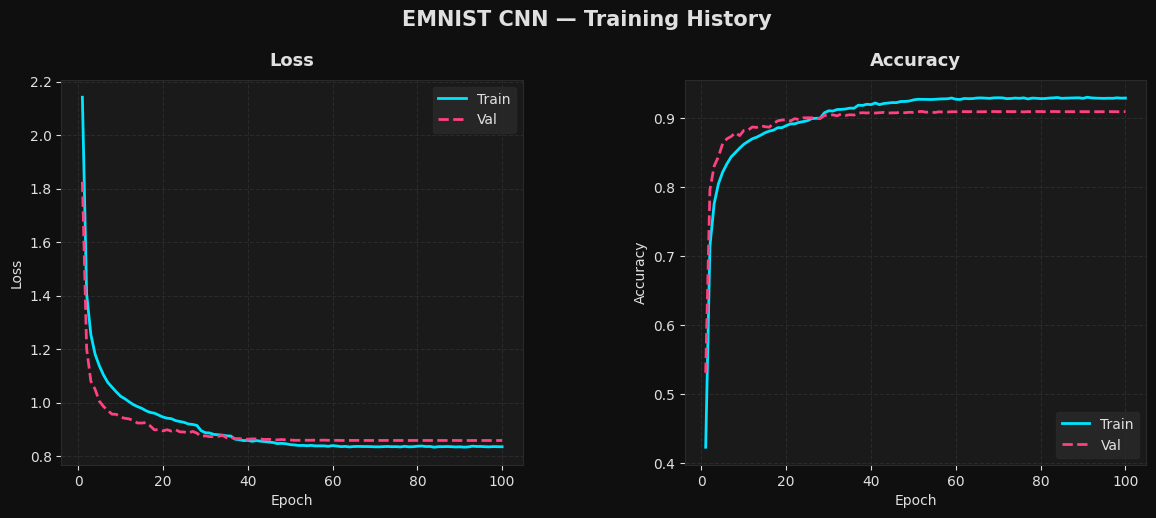

In [32]:
import os

# 1. Tentukan folder tempat menyimpan log TensorBoard
log_dir = os.path.join("logs", "emnist_cnn")

# 2. Inisialisasi TensorBoard Callback bawaan Keras
tensorboard_callback = keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,      # Mencatat distribusi bobot (weights) setiap epoch
    write_graph=True,      # Menyimpan grafik arsitektur model
    update_freq="epoch"    # Menulis log setiap akhir epoch (bisa diganti 'batch')
)

monitor = TrainingMonitor(patience=3, factor=0.5, filepath="best_model.keras")

history = model.fit(
    train_x, train_y,
    validation_data=(val_x, val_y),
    epochs=100,
    batch_size=128,
    verbose=1,
    callbacks=[monitor,
               keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
              tensorboard_callback],
)

plot_history(history)

In [33]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report

# ────────────────────────────────────────────────────────
# 1. LOAD MODEL PENUH SECARA LANGSUNG
# ────────────────────────────────────────────────────────
# Masukkan semua kelas/fungsi kustom Anda ke dalam custom_objects
print("★ Memuat model penuh dari file .keras...")
model = keras.models.load_model(
    "/kaggle/working/best_model.keras",
    custom_objects={
        "ChannelAttention": ChannelAttention,
        "LabelSmoothingCrossEntropy": LabelSmoothingCrossEntropy,
        "mish": mish
    }
)
print("★ Model berhasil dimuat sepenuhnya tanpa perlu rebuild arsitektur!")


# ── Inference ──────────────────────────────────────────
# Catatan: Karena model Anda mengembalikan 'logits' (belum dilewatkan ke Softmax),
# penggunaan np.argmax di sini sudah benar untuk mengambil indeks kelas tertinggi.
probs = model.predict(test_x)
preds = np.argmax(probs, axis=-1)

label_preds = []
label_test = []

for i in range(preds.shape[0]):
    label_preds.append([chr(65+int(preds[i]))])
    label_test.append([chr(65+int(test_y[i]))])

# ── Classification Report ───────────────────────────────
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(label_test, label_preds))

★ Memuat model penuh dari file .keras...
★ Model berhasil dimuat sepenuhnya tanpa perlu rebuild arsitektur!
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           A       1.00      0.94      0.97        34
           B       0.86      0.88      0.87        34
           C       0.88      0.88      0.88        34
           D       0.82      0.91      0.86        34
           E       0.94      0.83      0.88        35
           F       0.97      1.00      0.99        34
           G       0.86      0.74      0.79        34
           H       0.87      1.00      0.93        34
           I       0.82      0.79      0.81        34
           J       0.91      0.91      0.91        34
           K       0.94      0.97      0.96        35
           L       0.81      0.76      0.79        34
           M       1.00      1.00      1.00        34
           N       0.94      0.91      0.93        34
          

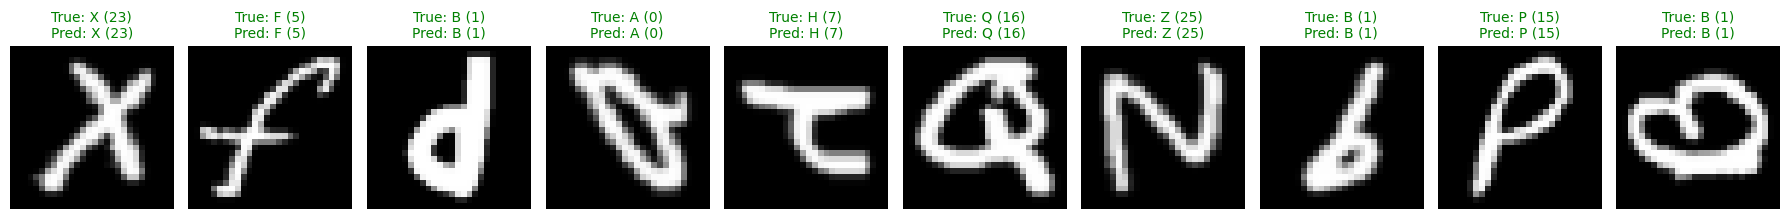

In [34]:
import matplotlib.pyplot as plt

# 1. Tentukan ukuran kanvas plot
plt.figure(figsize=(18, 4))

# 2. Loop untuk mengambil dan menampilkan 10 gambar pertama
for i in range(10):
    plt.subplot(1, 10, i + 1)
    
    # Squeeze digunakan jika gambar memiliki dimensi channel, misal (28, 28, 1) menjadi (28, 28)
    img = test_x[i].squeeze()
    plt.imshow(img, cmap='gray')
    
    # Ambil nilai indeks numerik asli dan prediksinya
    true_idx = int(test_y[i])
    pred_idx = int(preds[i])
    
    # Konversi indeks numerik ke karakter nyata (Sesuaikan dengan pergeseran 1-indexed)
    # Jika true_idx adalah 1, maka akan mengambil EMNIST_MAPPING[0] yaitu 'A'
    true_char = chr(65+pred_idx)
    pred_char = chr(65+pred_idx)
    
    # Beri warna hijau jika prediksi benar, dan merah jika salah
    title_color = 'green' if true_idx == pred_idx else 'red'
    
    # Tampilkan teks label di atas gambar
    plt.title(f"True: {true_char} ({true_idx})\nPred: {pred_char} ({pred_idx})", 
              fontsize=10, color=title_color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
!pip install fastapi uvicorn pyngrok nest-asyncio

In [13]:
import os
from pyngrok import ngrok

# 1. Masukkan authtoken ngrok Anda di sini
NGROK_TOKEN = "3EMLXdLXO3ZrMHsVwlnHYHG7sjA_2V4KB9CQjMnEcfjCbKn9g"
ngrok.set_auth_token(NGROK_TOKEN)

# 2. Buat folder log jika belum ada (sesuaikan dengan callback training Anda)
LOG_DIR = "./logs"
os.makedirs(LOG_DIR, exist_ok=True)

# 3. Jalankan TensorBoard di latar belakang (background process)
get_ipython().system_raw(f"tensorboard --logdir {LOG_DIR} --host 0.0.0.0 --port 6006 &")

# 4. Buka tunnel publik untuk TensorBoard
tb_tunnel = ngrok.connect(6006, "http")
print(f"★ TensorBoard URL: {tb_tunnel.public_url}")

★ TensorBoard URL: https://abnormal-overbid-cycling.ngrok-free.dev


2026-05-30 05:42:45.751664: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780119765.779725     226 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780119765.788762     226 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780119765.812998     226 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780119765.813034     226 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780119765.813036     226 computation_placer.cc:177] computation placer alr

In [6]:
import asyncio
import nest_asyncio
import uvicorn
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pyngrok import ngrok

# 1. Izinkan bersarangnya event loop di Jupyter Notebook
nest_asyncio.apply()

app = FastAPI(title="EMNIST Inference & TensorBoard API")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

@app.get("/")
def read_root():
    return {"message": "FastAPI di Kaggle berhasil berjalan!", "status": "healthy"}

@app.get("/api/status")
def get_status():
    return {"tensorboard_connected": True, "log_directory": "./logs"}

# 2. Nyalakan Ngrok Tunnel (Port 8000)
try:
    api_tunnel = ngrok.connect(8000, "http")
    print(f"★ FastAPI URL Public: {api_tunnel.public_url}")
    print(f"★ Swagger UI Docs: {api_tunnel.public_url}/docs")
except Exception as e:
    print(f"Ngrok error atau tunnel sudah terbuka: {e}")

# ────────────────────────────────────────────────────────
# 3. SOLUSI FIX RUNTIME ERROR (Python 3.12+ Jupyter)
# ────────────────────────────────────────────────────────
# Kita buat konfigurasi Uvicorn secara manual
config = uvicorn.Config(app=app, host="0.0.0.0", port=8000, loop="asyncio")
server = uvicorn.Server(config)

# Ambil event loop Jupyter yang sedang berjalan, lalu daftarkan server ke dalamnya
loop = asyncio.get_event_loop()
loop.create_task(server.serve())

★ FastAPI URL Public: https://abnormal-overbid-cycling.ngrok-free.dev
★ Swagger UI Docs: https://abnormal-overbid-cycling.ngrok-free.dev/docs


<Task pending name='Task-1' coro=<Server.serve() running at /usr/local/lib/python3.12/dist-packages/uvicorn/server.py:77>>

INFO:     Started server process [57]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     118.99.73.125:0 - "GET / HTTP/1.1" 200 OK
INFO:     118.99.73.125:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     118.99.73.125:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     118.99.73.125:0 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     118.99.73.125:0 - "GET / HTTP/1.1" 200 OK
INFO:     118.99.73.125:0 - "GET / HTTP/1.1" 200 OK


In [14]:
ngrok.kill()

In [16]:
import asyncio
import nest_asyncio
import uvicorn
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
from pyngrok import ngrok
import io
# import cv2  # Jika Anda menggunakan OpenCV untuk preprocessing
# import numpy as np # Biasanya dipakai untuk manipulasi matriks gambar

# 1. Izinkan bersarangnya event loop di Jupyter Notebook
nest_asyncio.apply()

app = FastAPI(title="EMNIST Inference & TensorBoard API")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

@app.get("/")
def read_root():
    return {"message": "FastAPI di Kaggle berhasil berjalan!", "status": "healthy"}

@app.get("/api/status")
def get_status():
    return {"tensorboard_connected": True, "log_directory": "./logs"}

# ────────────────────────────────────────────────────────
# ENDPOINT BARU: UNTUK TESTING INFERENCE GAMBAR
# ────────────────────────────────────────────────────────
@app.post("/predict")
async def predict_image(file: UploadFile = File(...)):
    try:
        # 1. Membaca file gambar yang diunggah menjadi bytes
        contents = await file.read()
        
        # 2. SEBAGAI CONTOH: Cek ukuran file untuk memastikan gambar masuk
        file_size = len(contents)
        
        # 3. PIL (Pillow) atau OpenCV bisa membaca bytes ini
        # contoh dengan PIL:
        # from PIL import Image
        # image = Image.open(io.BytesIO(contents)).convert('L') # Convert ke Grayscale untuk EMNIST
        # image = image.resize((28, 28)) # Resize ke ukuran EMNIST 28x28
        
        # 4. Pembungkus logika model EMNIST Anda nanti di sini:
        # input_tensor = np.array(image) / 255.0
        # prediction = model.predict(input_tensor)
        
        # Dummy response untuk testing apakah API menerima file dengan benar
        return {
            "status": "success",
            "filename": file.filename,
            "content_type": file.content_type,
            "bytes_received": file_size,
            "message": "Gambar berhasil diterima di Kaggle! Siap di-inferensi.",
            "dummy_prediction": "A" # Nanti ganti dengan hasil prediksi model asli Anda
        }
        
    except Exception as e:
        return {"status": "error", "message": str(e)}

# 2. Nyalakan Ngrok Tunnel (Port 8000)
try:
    # Rekomendasi: Masukkan authtoken ngrok Anda jika belum, agar tidak terkena limit session
    # ngrok.set_auth_token("TOKEN_ANDA") 
    api_tunnel = ngrok.connect(8000, "http")
    print(f"★ FastAPI URL Public: {api_tunnel.public_url}")
    print(f"★ Swagger UI Docs: {api_tunnel.public_url}/docs")
except Exception as e:
    print(f"Ngrok error atau tunnel sudah terbuka: {e}")

# 3. SOLUSI FIX RUNTIME ERROR (Python 3.12+ Jupyter)
config = uvicorn.Config(app=app, host="0.0.0.0", port=8000, loop="asyncio")
server = uvicorn.Server(config)

loop = asyncio.get_event_loop()
loop.create_task(server.serve())

<Task pending name='Task-1' coro=<Server.serve() running at /usr/local/lib/python3.12/dist-packages/uvicorn/server.py:77>>

INFO:     Started server process [2225]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


In [ ]:
import os
import io
import base64
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from fastapi import FastAPI, Security, HTTPException, status
from fastapi.security.api_key import APIKeyHeader
from pydantic import BaseModel

# ─────────────────────────────────────────
# 1. DEFINISI CUSTOM LAYER CORNERSTONES
# ─────────────────────────────────────────
class ChannelAttention(layers.Layer):
    def __init__(self, reduction_ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap = layers.GlobalAveragePooling2D()
        self.fc1 = layers.Dense(max(1, channels // self.reduction_ratio), activation="relu")
        self.fc2 = layers.Dense(channels, activation="sigmoid")
        self.reshape = layers.Reshape((1, 1, channels))

    def call(self, x):
        scale = self.gap(x)
        scale = self.fc1(scale)
        scale = self.fc2(scale)
        scale = self.reshape(scale)
        return x * scale

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"reduction_ratio": self.reduction_ratio})
        return cfg

class LabelSmoothingCrossEntropy(keras.losses.Loss):
    def __init__(self, smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.smoothing = smoothing

    def call(self, y_true, y_pred):
        num_classes = tf.cast(tf.shape(y_pred)[-1], tf.float32)
        y_true = tf.cast(y_true, tf.float32)
        if len(y_true.shape) == 1 or (len(y_true.shape) == 2 and y_true.shape[-1] == 1):
            y_true = tf.one_hot(tf.cast(tf.reshape(y_true, [-1]), tf.int32), tf.cast(num_classes, tf.int32))
        smooth_labels = y_true * (1.0 - self.smoothing) + self.smoothing / num_classes
        log_probs = tf.nn.log_softmax(y_pred, axis=-1)
        loss = -tf.reduce_sum(smooth_labels * log_probs, axis=-1)
        return tf.reduce_mean(loss)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"smoothing": self.smoothing})
        return cfg

def mish(x):
    return x * tf.math.tanh(tf.math.softplus(x))

# Map index EMNIST Anda ke Karakter Nyata (Sesuaikan urutan ini dengan label training Anda!)
EMNIST_MAPPING = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz" 

# ─────────────────────────────────────────
# 2. INITIALIZE FASTAPI & LOAD MODEL
# ─────────────────────────────────────────
app = FastAPI(title="EMNIST Complete Grid Sheet OCR API")

API_KEY_NAME = "X-API-Key"
api_key_header = APIKeyHeader(name=API_KEY_NAME, auto_error=False)
API_KEY = os.environ.get("MY_SECRET_API_KEY", "KunciRahasia123!")

model = keras.models.load_model(
    "best_model.keras",
    custom_objects={
        "ChannelAttention": ChannelAttention,
        "LabelSmoothingCrossEntropy": LabelSmoothingCrossEntropy,
        "mish": mish
    }
)

async def get_api_key(api_key_header: str = Security(api_key_header)):
    if api_key_header == API_KEY: return api_key_header
    raise HTTPException(status_code=status.HTTP_403_FORBIDDEN, detail="Invalid API Key")

# Skema Request Input untuk menerima gambar Base64 dari Web Frontend
class ImageInput(BaseModel):
    image_base64: str

@app.get("/")
def home():
    return {"status": "OCR Engine Active"}

# ─────────────────────────────────────────
# 3. ENDPOINT INFERENCE DENGAN LOGIKA GRID
# ─────────────────────────────────────────
@app.post("/predict-sheet", dependencies=[Security(get_api_key)])
def predict_sheet(payload: ImageInput):
    try:
        # Decode gambar base64 yang dikirim frontend ke format OpenCV Mat
        encoded_data = payload.image_base64.split(",")[-1]
        nparr = np.frombuffer(base64.b64decode(encoded_data), np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        
        if img is None:
            raise HTTPException(status_code=400, detail="Format gambar tidak valid.")

        # Preprocessing ke Grayscale dan Thresholding biner
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

        # --- LOGIKA SEPARASI GRID ANDA ---
        scale = 28 
        horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (scale, 1))
        vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, scale))
        detect_horizontal = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)
        detect_vertical = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, vertical_kernel, iterations=2)

        clean_grid_mask = cv2.addWeighted(detect_horizontal, 0.5, detect_vertical, 0.5, 0)
        clean_grid_mask = cv2.threshold(clean_grid_mask, 10, 255, cv2.THRESH_BINARY)[1]

        contours, _ = cv2.findContours(clean_grid_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        valid_boxes = []
        for contour in contours:
            x, y, w, h = cv2.boundingRect(contour)
            if 20 < w < 200 and 20 < h < 200:
                valid_boxes.append((x, y, w, h))

        if not valid_boxes:
            return {"status": "success", "text": ""}

        # Sort & Grouping kotak ke baris-baris (Row-by-Row)
        valid_boxes = sorted(valid_boxes, key=lambda b: b[1])
        rows = []
        current_row = []
        prev_y = valid_boxes[0][1]
        cell_height_threshold = 20  

        for box in valid_boxes:
            if abs(box[1] - prev_y) > cell_height_threshold:
                rows.append(sorted(current_row, key=lambda b: b[0]))
                current_row = [box]
                prev_y = box[1]
            else:
                current_row.append(box)
        if current_row:
            rows.append(sorted(current_row, key=lambda b: b[0]))

        # --- PROSES EVALUASI KOTAK BLANK VS MODEL PREDICT ---
        extracted_text = []

        for row in rows:
            space_allocated = False
            has_content_yet = False
            row_text = ""
            
            for x, y, w, h in row:
                padding = 5
                cropped_thresh_cell = thresh[y+padding : y+h-padding, x+padding : x+w-padding]
                
                # Proteksi ukuran jika cropping di tepi gambar bermasalah
                if cropped_thresh_cell.size == 0:
                    continue
                    
                text_pixel_count = cv2.countNonZero(cropped_thresh_cell)
                total_pixels = cropped_thresh_cell.shape[0] * cropped_thresh_cell.shape[1]
                text_ratio = (text_pixel_count / total_pixels) * 100
                
                is_blank = text_ratio <= 1.5
                
                if not is_blank:
                    # ADA ISI -> Resize kotak ke (28, 28) untuk dimasukkan ke model Keras
                    cell_resized = cv2.resize(cropped_thresh_cell, (28, 28), interpolation=cv2.INTER_AREA)
                    
                    # Normalisasi data pixel 0.0 - 1.0
                    cell_input = cell_resized.astype(np.float32) / 255.0
                    cell_input = np.expand_dims(cell_input, axis=(0, -1)) # Shape menjadi (1, 28, 28, 1)
                    
                    # Prediksi menggunakan model
                    logits = model.predict(cell_input, verbose=0)
                    pred_idx = np.argmax(logits, axis=-1)[0]
                    
                    # Terjemahkan index angka ke karakter asli string
                    char_result = EMNIST_MAPPING[pred_idx] if pred_idx < len(EMNIST_MAPPING) else "?"
                    row_text += char_result
                    
                    has_content_yet = True
                    space_allocated = False 
                else:
                    # KOTAK BLANK -> Simpan spasi hanya untuk space pertama pasca konten teks
                    if has_content_yet and not space_allocated:
                        row_text += " "  # <-- DI SINI JADI SPASI
                        space_allocated = True
            
            if row_text.strip():  # Masukkan baris jika tidak sepenuhnya kosong
                extracted_text.append(row_text.rstrip())

        # Gabungkan semua baris teks dengan pemisah baris baru (\n)
        final_output_string = "\n".join(extracted_text)

        return {
            "status": "success",
            "result_text": final_output_string
        }
        
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Gagal memproses kertas grid: {str(e)}")